# Quantum Computing Setup & Workflow

Design, optimize and run a quantum circuit on real IBM Quantum Hardware using Qiskit

In [2]:
import qiskit

# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

In [3]:
qiskit.__version__

'2.3.0'

## Backend Setup

In [5]:
import json

with open('apikey.json', 'r') as file:
    data = json.load(file)

In [6]:
apikey = data['apikey']

In [7]:
## Load the Qiskit Runtime service
# QiskitRuntimeService.save_account(
#    channel="ibm_quantum_platform",
#    token="YOUR_TOKEN_HERE",
#    overwrite=True,
#    set_as_default=True,
# )
# service = QiskitRuntimeService(channel="ibm_quantum_platform")

service = QiskitRuntimeService()

qiskit_runtime_service.__init__:WARNING:2026-06-15 20:39:34,674: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [8]:
backend = service.backend(name = "ibm_kingston")

qiskit_runtime_service.backends:WARNING:2026-06-15 20:39:35,997: Using instance: open-instance, plan: open


In [9]:
backend.num_qubits

156

## Qiskit patterns workflow

The Qiskit patterns workflow is a general framework for solving quantum problems in Qiskit. It breaks a quantum computing task into four steps:

- Map the problem to a model that can be represented by quantum circuits
- Optimize the circuit to be run on a specific backend
- Execute the optimized circuit on the selected backend
- Post-process the raw measurement data

## Circuit construction

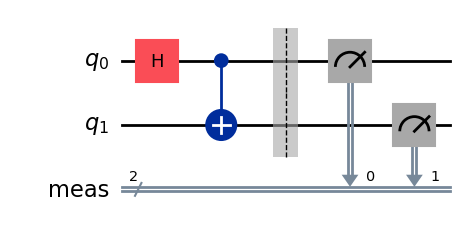

In [2]:
# --- Build the Bell circuit (phi-plus) ---
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()  # creates a classical register named "meas"

bell.draw("mpl")

## Helper function: Circuit optimization and execution

In [3]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

## Configure backend

In [4]:
# Load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_fez")
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-06-09 22:20:59,559: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-09 22:21:00,154: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-09 22:21:03,713: Using instance: open-instance, plan: open


ibm_fez


## Execute circuit and plot results

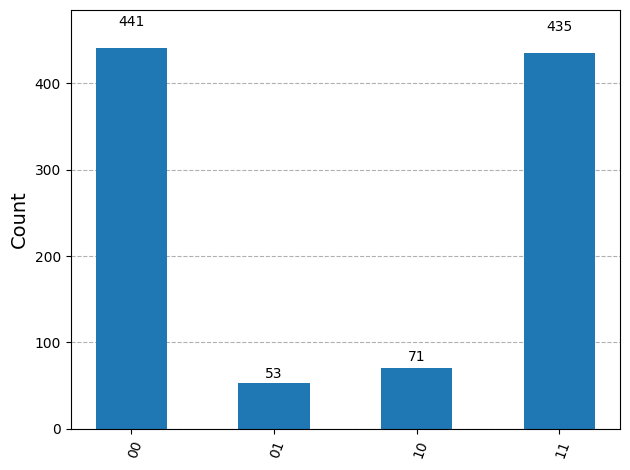

In [5]:
counts = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts)

## Simulation Results

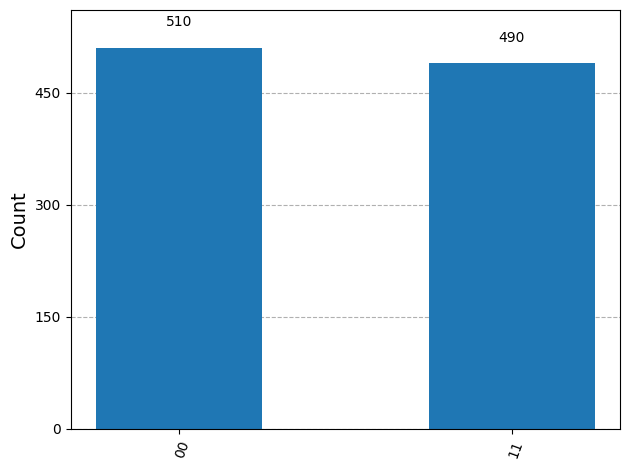

In [6]:
backend = AerSimulator()
counts = run_circuit_and_get_counts(bell, backend, shots=1000)

plot_histogram(counts)

## Modeling Two Interacting Magnets

The two magnets are mapped as two separate qubits. If their signs are different they anti-align. We will represent this as a quantum circuit using the $|\psi^-\rangle$ bell state.

$$|\psi^-\rangle = \frac{1}{\sqrt{2}} \left( |01\rangle - |10\rangle \right)$$

We will use both `Sampler` to measure the state and `Estimator` to find the energy of the system.

### Step1: Model problem as Quantum Circuit

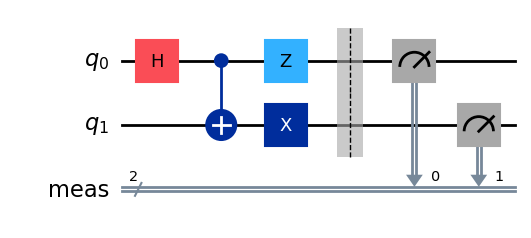

In [25]:
# Import Qiskit primitives
from qiskit import QuantumCircuit

# Make state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

# Measure state
qc.measure_all()

# Draw circuit
qc.draw("mpl")

### Step2: Optimize the Circuit for a specific backend

In [26]:
# Load the Qiskit Runtime service
from qiskit_ibm_runtime import QiskitRuntimeService

## Load the Qiskit Runtime service
# QiskitRuntimeService.save_account(
#    channel="ibm_quantum_platform",
#    token="YOUR_TOKEN_HERE",
#    overwrite=True,
#    set_as_default=True,
# )
# service = QiskitRuntimeService(channel="ibm_quantum_platform")


# Or load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_brisbane")
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-06-15 21:35:59,053: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-15 21:35:59,676: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-15 21:36:04,299: Using instance: open-instance, plan: open


ibm_kingston


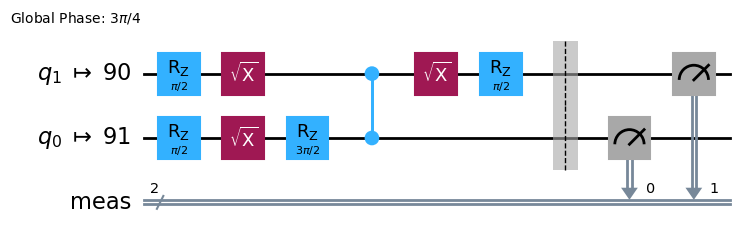

In [27]:
# Transpile the circuit and optimize for running on the quantum computer selected
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

qc_isa.draw("mpl")

### Step3: Execute the optimized circuit

In [28]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

If using a simulator instead, uncomment the code below.

In [30]:
## Load the backend sampler
# from qiskit.primitives import BackendSamplerV2

## Load the Aer simulator and generate a noise model based on the currently-selected backend.
# from qiskit_aer import AerSimulator
# from qiskit_aer.noise import NoiseModel

# noise_model = NoiseModel.from_backend(backend)

## Define a simulator using Aer, and use it in Sampler.
# backend_sim = AerSimulator(noise_model=noise_model)
# sampler_sim = BackendSamplerV2(backend=backend_sim)

## Alternatively, load a fake backend with generic properties and define a simulator.
## backend_gen = GenericBackendV2(num_qubits=18)
## sampler_gen = BackendSamplerV2(backend=backend_gen)

In [29]:
job = sampler.run([qc_isa], shots=100)
# job = sampler_sim.run([qc_isa]) # uncomment if you want to run on a simulator
res = job.result()
counts = res[0].data.meas.get_counts()

### Step4: Post process the measurement data

counts =  {'10': 48, '01': 50, '11': 2}


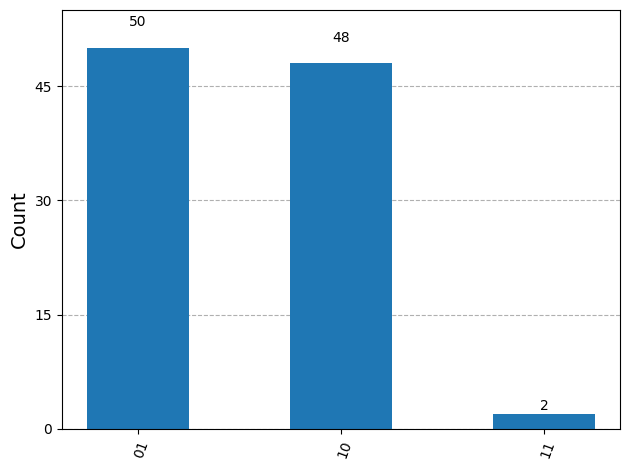

In [31]:
from qiskit.visualization import plot_histogram

print("counts = ", counts)
plot_histogram(counts)

### Using Estimator to compute the energy of the state 

In [32]:
# Import Qiskit primitives
from qiskit.quantum_info import SparsePauliOp

# Parameters
J = 1.0  # antiferromagnetic coupling (J<0)
hx = -0.5  # transverse field strength

# 1. Define the Hamiltonian H = J Z1 Z2 + hx (X1 + X2)
obs = SparsePauliOp.from_list([("ZZ", J), ("XI", hx), ("IX", hx)])

# Make state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

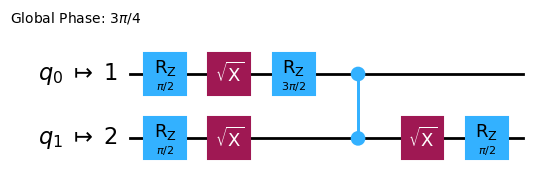

In [33]:
# Transpile the circuit and optimize for running on the quantum computer selected
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

qc_isa.draw("mpl")

In [34]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

In [35]:
# Load the backend sampler

# noise_model = NoiseModel.from_backend(backend)

# Use Aer simulator in Estimator
# estimator_sim = BackendEstimatorV2(backend=backend_sim)

# Alternatively, load a fake backend with generic properties and define a simulator.
# backend_gen = GenericBackendV2(num_qubits=18)
# estimator_gen = BackendEstimatorV2(backend=backend_gen)

In [36]:
pubs = [(qc_isa, obs_isa)]
job = estimator.run([[qc_isa, obs_isa]])
res = job.result()

# Uncomment lines below to run the job on the Aer simulator with noise model from real backend
# job = estimator_sim.run([[qc_isa,obs_isa]])
# res=job.result()

In [37]:
print("Energy of state:", res[0].data.evs)

Energy of state: -0.9791244095071634
